In [ ]:
#==================
# Import packages
#==================

import os
import glob
import numpy as np
from tifffile import imread
import random


import matplotlib.pyplot as plt

from scipy.ndimage import map_coordinates
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:


#============================
# Random tiff loader function
#============================
def load_tiff_folder(folder, lottery):

    file_list = sorted(glob.glob(os.path.join(folder, "*.tiff")))
    # Reproducibility (optional)
    random.seed(lottery)
    
    # Safety check
    n_select = min(20, len(file_list))

    # Random sample of 20 Tiff images
    selected_files = random.sample(file_list, n_select)

    imgs = [imread(f).astype(np.float32) for f in selected_files]
    return imgs, selected_files




#========================================================================
# Directories for blank, Ti, and Nb data. Update to your folder structure
#========================================================================
blank = '/Users/spuplampu/camm_hackathon/day_14/Background Removal Data Nb blank Ti/blank'
Nb = '/Users/spuplampu/camm_hackathon/day_14/Background Removal Data Nb blank Ti/Nb'
Ti = '/Users/spuplampu/camm_hackathon/day_14/Background Removal Data Nb blank Ti/Ti'

seedy = 42 # seed choice for repeatability

blank_imgs, blank_files = load_tiff_folder(blank, seedy)
ti_imgs, ti_files       = load_tiff_folder(Ti, seedy)
nb_imgs, nb_files       = load_tiff_folder(Nb, seedy)

print("Blank:", len(blank_imgs))
print("Ti:", len(ti_imgs))
print("Nb:", len(nb_imgs))

Blank: 20
Ti: 20
Nb: 20


In [ ]:
# Center coordinates obtained from Josh Safin's source code
center_x = 1013
center_y = 242

# These can be played with to explore PCA performance
n_radial = 800
n_angular = 720

# These can be played with to explore PCA performance
r_min = 0
r_max = 1000

In [20]:


# ============================================================
# POLAR TRANSFORM
# ============================================================

def cartesian_to_polar(
    image,
    center,
    r_min,
    r_max,
    n_radial,
    n_angular
):
    """
    Convert detector image to polar coordinates.

    Output shape:
        (n_radial, n_angular)
    """

    cy, cx = center

    # radial coordinate
    r = np.linspace(r_min, r_max, n_radial)

    # azimuthal coordinate
    theta = np.linspace(0, 2*np.pi, n_angular)

    rr, tt = np.meshgrid(r, theta, indexing='ij')

    # polar -> cartesian
    x = cx + rr * np.cos(tt)
    y = cy + rr * np.sin(tt)

    coords = np.vstack((y.ravel(), x.ravel()))

    polar = map_coordinates(
        image,
        coords,
        order=1,
        mode='constant',
        cval=0
    )

    polar = polar.reshape((n_radial, n_angular))

    return polar


In [ ]:
def preprocess(images):
    out = []

    for img in images:

        polar = cartesian_to_polar(
            img,
            center=(center_y, center_x),
            r_min=r_min,
            r_max=r_max,
            n_radial=n_radial,
            n_angular=n_angular
        )

        # safety cleanup, getting rid of nan values
        polar = np.nan_to_num(polar, nan=0.0, posinf=0.0, neginf=0.0)

        # log intensity
        polar = np.log1p(polar)

        # normalize (important: keep consistent scaling)
        polar /= np.percentile(polar, 99)

        out.append(polar)

    return np.array(out)


blank_polar = preprocess(blank_imgs)
ti_polar    = preprocess(ti_imgs)
nb_polar    = preprocess(nb_imgs)

print(blank_polar.shape, ti_polar.shape, nb_polar.shape)

(20, 800, 720) (20, 800, 720) (20, 800, 720)


In [ ]:
#==========================
# 8-component PCA analysis
#==========================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Number of components can be tweaked to evaluate performance
n_components = 8

X_blank = blank_polar.reshape(len(blank_polar), -1)
X_blank = np.nan_to_num(X_blank)

scaler = StandardScaler(with_mean=True, with_std=False)
X_blank_scaled = scaler.fit_transform(X_blank)

pca = PCA(n_components=n_components)
pca.fit(X_blank_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.06932114 0.05803446 0.05746339 0.05733566 0.05591186 0.05585975
 0.05515855 0.0548669 ]


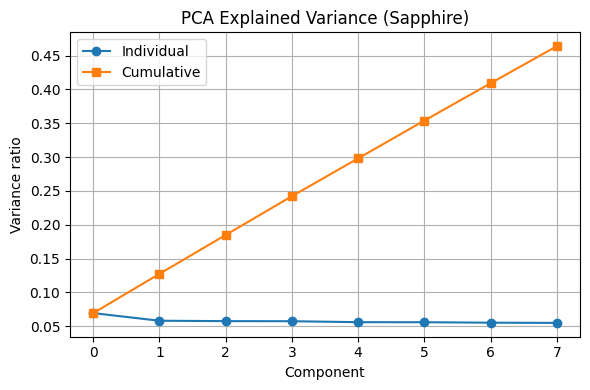

In [38]:


evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

plt.figure(figsize=(6,4))
plt.plot(evr, marker='o', label='Individual')
plt.plot(cumulative, marker='s', label='Cumulative')

plt.title("PCA Explained Variance (Sapphire)")
plt.xlabel("Component")
plt.ylabel("Variance ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

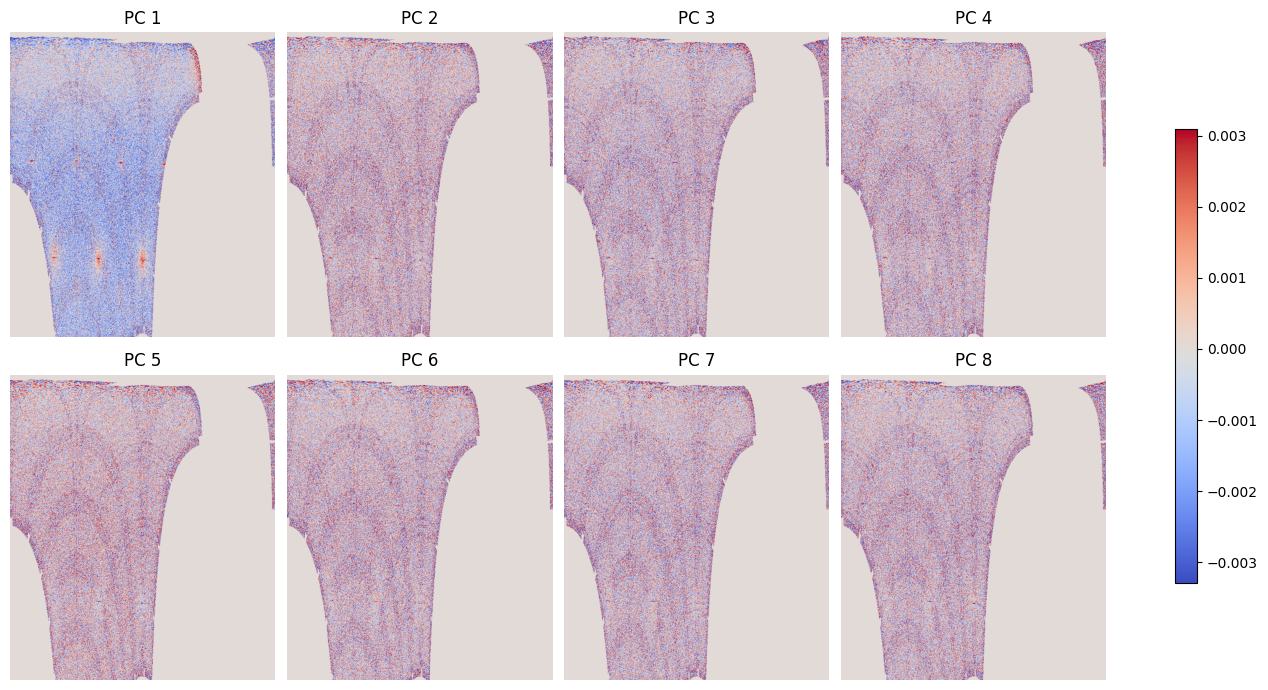

In [73]:
import numpy as np
import matplotlib.pyplot as plt

n_show = min(n_components, 8)

# collect all components you will plot
all_vals = []
for i in range(n_show):
    comp = pca.components_[i].reshape(n_radial, n_angular)
    all_vals.append(comp)

all_vals = np.concatenate([c.ravel() for c in all_vals])

# robust limits (VERY important for PCA)
vmin, vmax = np.percentile(all_vals, [2, 98])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i in range(n_show):
    comp = pca.components_[i].reshape(n_radial, n_angular)

    im = axes[i].imshow(
        comp,
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        aspect='auto'
    )

    axes[i].set_title(f"PC {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axes, shrink=0.7)
plt.show()

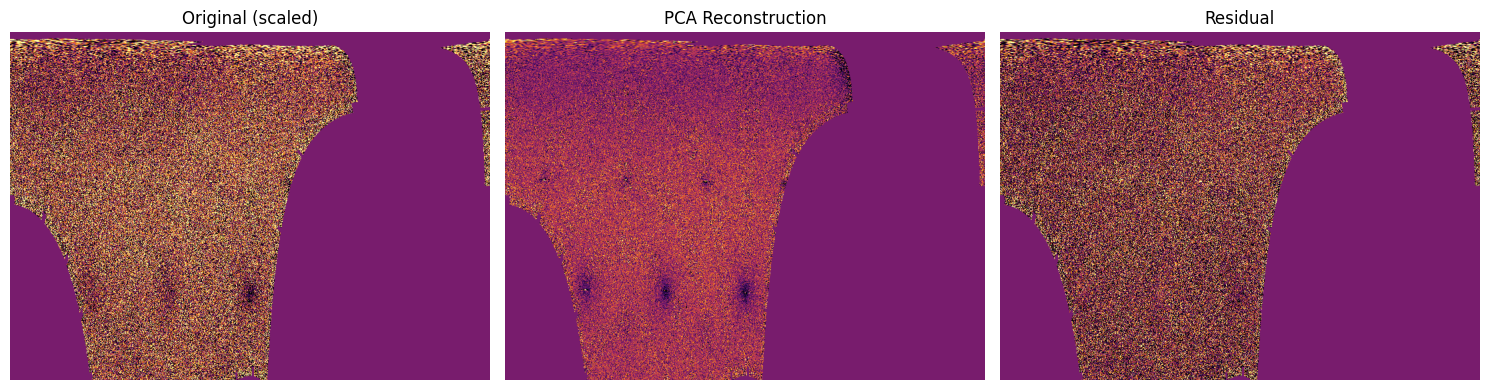

In [ ]:
X_recon = pca.inverse_transform(pca.transform(X_blank_scaled))

idx = 0 # change index as needed to view correction applied to the randomly selected 20 images

orig = X_blank_scaled[idx].reshape(n_radial, n_angular)
recon = X_recon[idx].reshape(n_radial, n_angular)
resid = orig - recon

vmin=-0.01
vmax=0.02

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].imshow(orig, cmap='inferno', vmin=vmin, vmax=vmax, aspect='auto')
ax[0].set_title("Original (scaled)")

ax[1].imshow(recon, cmap='inferno', vmin=vmin, vmax=vmax, aspect='auto')
ax[1].set_title("PCA Reconstruction")

ax[2].imshow(resid, cmap='inferno', vmin=vmin, vmax=vmax, aspect='auto')
ax[2].set_title("Residual") #not sure if this residual makes sense... 


for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

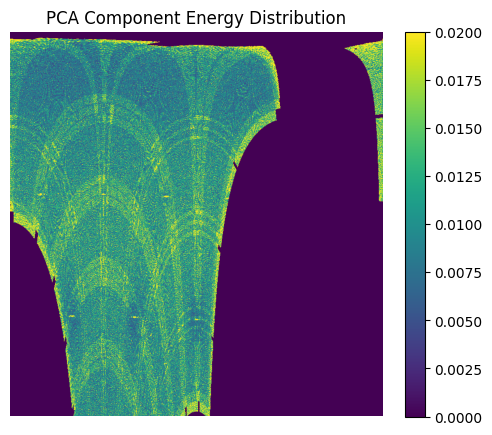

In [47]:
#===================================================
# This shows where PCA is “looking” in the detector.
#===================================================
energy_map = np.zeros(n_radial * n_angular)

for i in range(n_components):
    energy_map += np.abs(pca.components_[i])

energy_map = energy_map.reshape(n_radial, n_angular)

plt.figure(figsize=(6,5))
plt.imshow(energy_map, cmap='viridis', aspect='auto', vmin=0, vmax=0.02)
plt.title("PCA Component Energy Distribution")
plt.colorbar()
plt.axis("off")
plt.show()

In [ ]:
def project_and_reconstruct(polar_stack, scaler, pca):

    X = polar_stack.reshape(len(polar_stack), -1)
    X = np.nan_to_num(X)

    Xs = scaler.transform(X)

    coeffs = pca.transform(Xs)
    recon  = pca.inverse_transform(coeffs)

    residual = Xs - recon

    return (
        recon.reshape(polar_stack.shape),
        residual.reshape(polar_stack.shape)
    )

In [24]:
ti_recon, ti_residual = project_and_reconstruct(ti_polar, scaler, pca)
nb_recon, nb_residual = project_and_reconstruct(nb_polar, scaler, pca)

print("Done decomposition")

Done decomposition


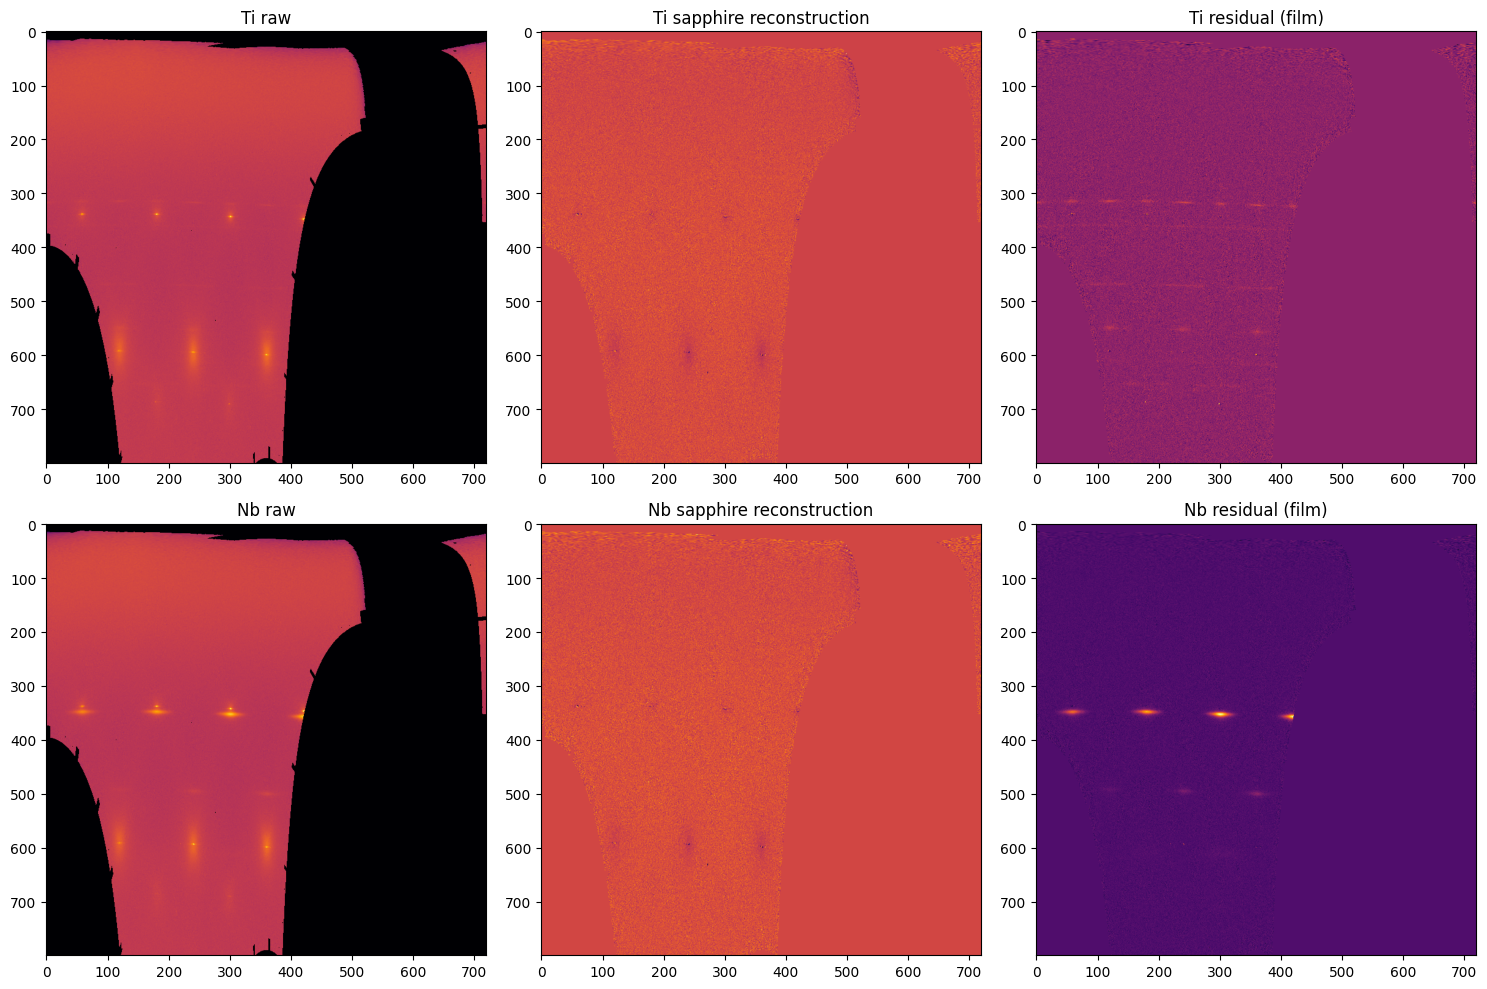

In [ ]:
# Image in polar coordinates after sapphire PCA is applied to Ti and Nb PCA 

import matplotlib.pyplot as plt

i = 14 # change index as needed to view correction applied to the randomly selected 20 images

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

# TI
ax[0,0].imshow(ti_polar[i], cmap='inferno', aspect='auto')
ax[0,0].set_title("Ti raw")

ax[0,1].imshow(ti_recon[i], cmap='inferno', aspect='auto')
ax[0,1].set_title("Ti sapphire reconstruction")

ax[0,2].imshow(ti_residual[i], cmap='inferno', aspect='auto')
ax[0,2].set_title("Ti residual (film)")

# NB
ax[1,0].imshow(nb_polar[i], cmap='inferno', aspect='auto')
ax[1,0].set_title("Nb raw")

ax[1,1].imshow(nb_recon[i], cmap='inferno', aspect='auto')
ax[1,1].set_title("Nb sapphire reconstruction")

ax[1,2].imshow(nb_residual[i], cmap='inferno', aspect='auto')
ax[1,2].set_title("Nb residual (film)")

plt.tight_layout()
plt.show()

In [ ]:
#image shape check

print(blank_imgs[0].shape)

(1733, 1529)


In [ ]:
# checking available radius

h, w = blank_imgs[0].shape

r_max = np.sqrt((w - center_x)**2 + (h - center_y)**2)
print("Max usable radius (pixels):", r_max)

Max usable radius (pixels): 1577.7632902308255


In [ ]:
# reverting to cartesian coordinates to visualize corrected patterns

def polar_to_cartesian(polar_img, center, r_min, r_max):
    """
    Convert (n_radial, n_angular) polar image back to Cartesian detector space.
    """

    cy, cx = center

    n_radial, n_angular = polar_img.shape

    r = np.linspace(r_min, r_max, n_radial)
    theta = np.linspace(0, 2*np.pi, n_angular)

    # Cartesian grid (output image shape must match original detector)
    h = int(2 * max(cy, polar_img.shape[0]))  # safe upper bound
    w = int(2 * max(cx, polar_img.shape[0]))

    yy, xx = np.indices((h, w))

    # shift origin to beam center
    x = xx - cx
    y = yy - cy

    rr = np.sqrt(x**2 + y**2)
    tt = np.arctan2(y, x) % (2*np.pi)

    # map rr, tt → polar indices
    r_idx = np.interp(rr, r, np.arange(n_radial))
    t_idx = np.interp(tt, theta, np.arange(n_angular))

    coords = np.vstack((r_idx.ravel(), t_idx.ravel()))

    cart = map_coordinates(
        polar_img,
        coords,
        order=1,
        mode='constant',
        cval=0.0
    )

    return cart.reshape(h, w)

In [ ]:
# Checking residual_cartesian shape

center = (center_y, center_x)

ti_residual_cart = [
    polar_to_cartesian(img, center, r_min, r_max)
    for img in ti_residual
]

nb_residual_cart = [
    polar_to_cartesian(img, center, r_min, r_max)
    for img in nb_residual
]

ti_residual_cart = np.array(ti_residual_cart)
nb_residual_cart = np.array(nb_residual_cart)

print(ti_residual_cart.shape, nb_residual_cart.shape)

(20, 1600, 2026) (20, 1600, 2026)


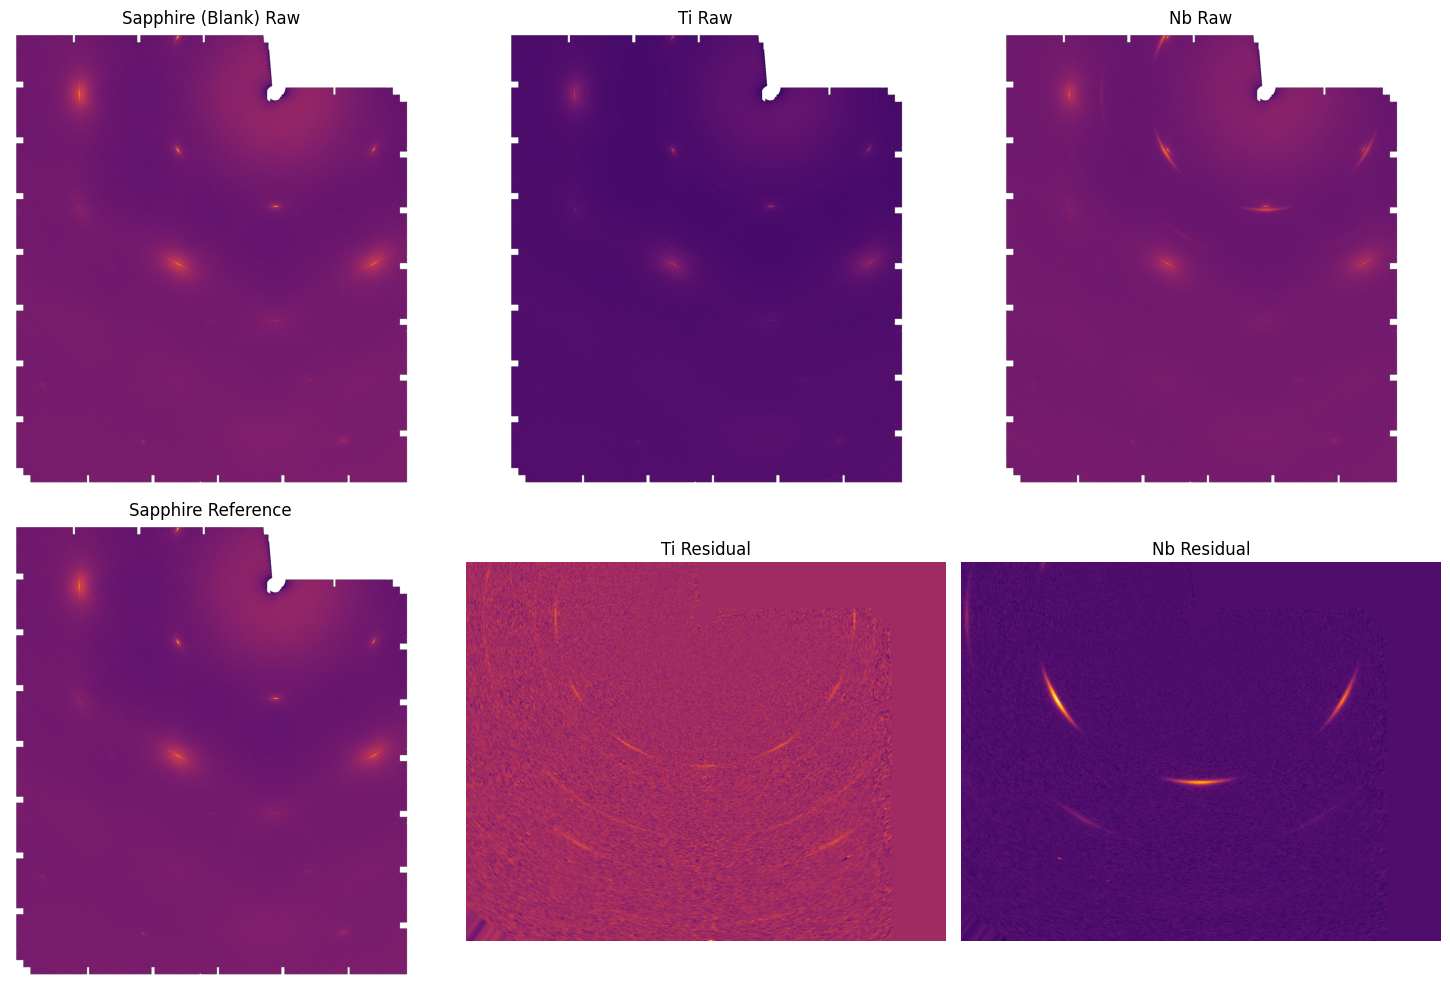

In [ ]:
# Compare cartesian diffraction patterns before and after correction

import numpy as np
import matplotlib.pyplot as plt

i = 14  # change index as needed to view correction applied to the randomly selected 20 images

fig, ax = plt.subplots(2, 3, figsize=(15, 10))


# -------------------------
# SAPPHIRE
# -------------------------
ax[0, 0].imshow(np.log1p(blank_imgs[i]), cmap='inferno')
ax[0, 0].set_title("Sapphire (Blank) Raw")
ax[0, 0].axis("off")

# -------------------------
# TI RAW / RESIDUAL
# -------------------------
ax[0, 1].imshow(np.log1p(ti_imgs[i]), cmap='inferno')
ax[0, 1].set_title("Ti Raw")
ax[0, 1].axis("off")

ax[1, 1].imshow(np.log1p(ti_residual_cart[i]), cmap='inferno')
ax[1, 1].set_title("Ti Residual")
ax[1, 1].axis("off")

# -------------------------
# NB RAW / RESIDUAL
# -------------------------
ax[0, 2].imshow(np.log1p(nb_imgs[i]), cmap='inferno')
ax[0, 2].set_title("Nb Raw")
ax[0, 2].axis("off")

ax[1, 2].imshow(np.log1p(nb_residual_cart[i]), cmap='inferno')
ax[1, 2].set_title("Nb Residual")
ax[1, 2].axis("off")

# optional: blank residual proxy (often useful)
ax[1, 0].imshow(np.log1p(blank_imgs[i]), cmap='inferno')
ax[1, 0].set_title("Sapphire Reference")
ax[1, 0].axis("off")

plt.tight_layout()
plt.show()

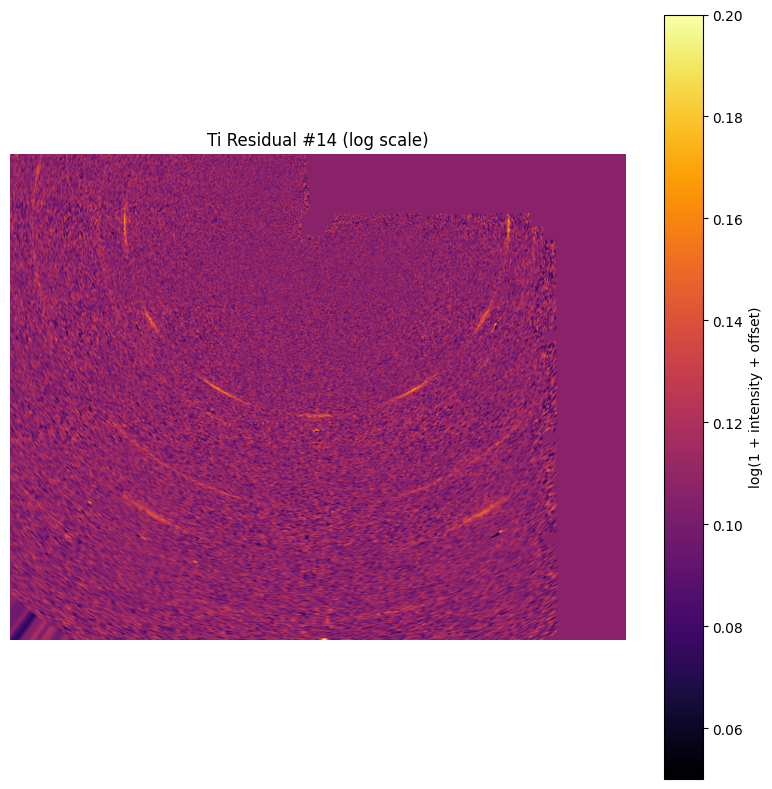

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Choose image index
# ---------------------------------------
i = 14

# ---------------------------------------
# Choose colormap limits
# Edit these manually
# ---------------------------------------
vmin = 0.05
vmax = 0.20

# ---------------------------------------
# Select image
# ---------------------------------------
img = ti_residual_cart[i]

# ---------------------------------------
# Safe log scaling
# ---------------------------------------
# residuals may contain negative values
# so shift image before log transform

offset = np.abs(img.min()) + 1e-6

img_log = np.log1p(img + offset)

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(8,8))

im = plt.imshow(
    img_log,
    cmap='inferno',
    vmin=vmin,
    vmax=vmax
)

plt.title(f"Ti Residual #{i} (log scale)")
plt.axis("off")

cbar = plt.colorbar(im)
cbar.set_label("log(1 + intensity + offset)")

plt.tight_layout()
plt.show()

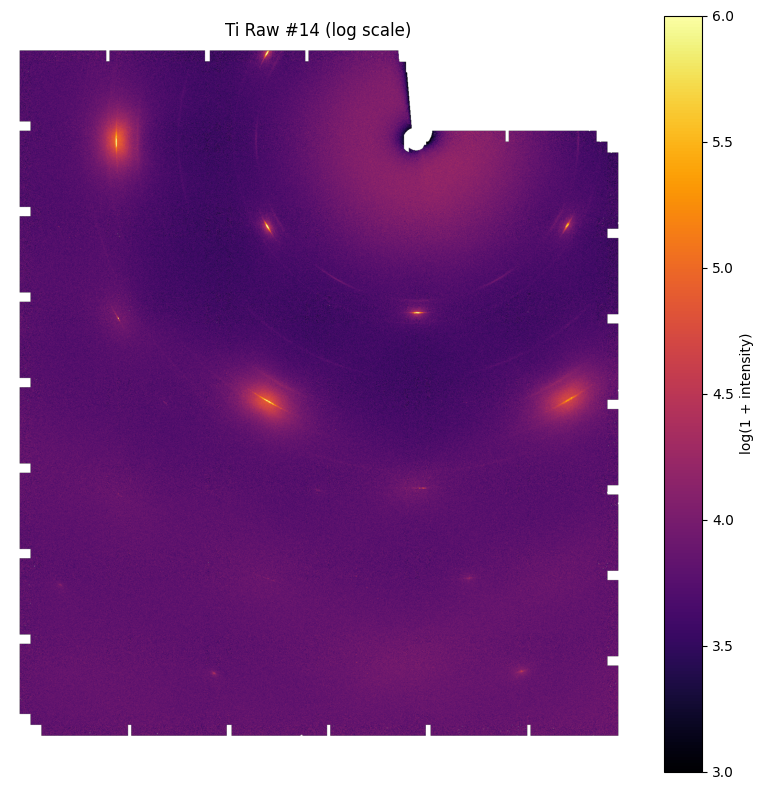

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Choose image index
# ---------------------------------------
i = 14

# ---------------------------------------
# Choose colormap limits
# Edit these manually
# ---------------------------------------
vmin = 3
vmax = 6

# ---------------------------------------
# Select image
# ---------------------------------------
img = ti_imgs[i]

# ---------------------------------------
# Log scaling
# ---------------------------------------
img_log = np.log1p(img)

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(8,8))

im = plt.imshow(
    img_log,
    cmap='inferno',
    vmin=vmin,
    vmax=vmax
)

plt.title(f"Ti Raw #{i} (log scale)")
plt.axis("off")

cbar = plt.colorbar(im)
cbar.set_label("log(1 + intensity)")

plt.tight_layout()
plt.show()